<span style="color: #FF5733; font-size: 30px; font-weight: bold;">
    Data cleaning using Python
</span>

<span style="color: #efe2df; font-size: 28px; font-weight: bold;">
    import libaries
</span>

In [ ]:
import pandas as pd
import numpy as np

<span style="blue: #FF5733; font-size: 28px; font-weight: bold;">
    read the excel file 
</span>

In [6]:
df= pd.read_excel("d:\\decodelab project\\Dataset for Data Analytics.xlsx")

<span style="color: #ead5d0; font-size: 28px; font-weight: bold;">
    check the info 
</span>

In [ ]:
df.info

<bound method DataFrame.info of         OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card   

In [ ]:
df['check_totalprice']=df['Quantity']*df['UnitPrice']

In [ ]:
df['check_totalprice']==df['TotalPrice']

0        True
1        True
2       False
3        True
4        True
        ...  
1195     True
1196     True
1197     True
1198     True
1199     True
Length: 1200, dtype: bool


<span style="blue: #FF5733; font-size: 28px; font-weight: bold;">
   I have checked for the quality of the total price by making a new check column and calculating the total price manually and all seems to be well.

</span>

In [ ]:
df.sample

<bound method NDFrame.sample of         OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card   

In [ ]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

<span style="color: #ead5d0; font-size: 28px; font-weight: bold;">
    Check for any missing or duplicated data
</span>

In [ ]:
df.isnull().any()

OrderID            False
Date               False
CustomerID         False
Product            False
Quantity           False
UnitPrice          False
ShippingAddress    False
PaymentMethod      False
OrderStatus        False
TrackingNumber     False
ItemsInCart        False
CouponCode          True
ReferralSource     False
TotalPrice         False
dtype: bool

In [ ]:
df.duplicated(['OrderID']).any()

np.False_

In [ ]:
df.dtypes

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Add new columns

In [ ]:
df['Is_Coupons']=df['CouponCode']

In [ ]:
print(df['Is_Coupons'].unique())

['SAVE10' 'FREESHIP' nan 'WINTER15']


In [ ]:
df['Is_Coupons']=df['Is_Coupons'].replace({'SAVE10':'Yes','FREESHIP':'Yes','WINTER15':'Yes'}, regex=True)

In [ ]:
df['Is_Coupons']= df['Is_Coupons'].fillna('No')

In [ ]:
df['Is_Coupons'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Month']=df['Date'].dt.month_name()

In [ ]:
df['Year']=df['Date'].dt.year


In [ ]:
df.dtypes

OrderID                     object
Date                datetime64[ns]
CustomerID                  object
Product                     object
Quantity                     int64
UnitPrice                  float64
ShippingAddress             object
PaymentMethod               object
OrderStatus                 object
TrackingNumber              object
ItemsInCart                  int64
CouponCode                  object
ReferralSource              object
TotalPrice                 float64
Is_Coupons                  object
Month                       object
Year                         int32
check_totalprice           float64
dtype: object

Drop Columns that has unimportant information

In [ ]:
drop_columns=df.drop(['TrackingNumber','check_totalprice'],axis=1)

<span style="color: #ead5d0; font-size: 28px; font-weight: bold;">
    Check for outliers
</span>

In [7]:
df['TotalPrice'].describe()

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

In [9]:
df['Quantity'].describe()

count    1200.000000
mean        2.945833
std         1.407557
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64

In [10]:
df['UnitPrice'].describe()

count    1200.000000
mean      356.412750
std       197.177146
min        11.390000
25%       186.062500
50%       364.210000
75%       521.570000
max       699.930000
Name: UnitPrice, dtype: float64

In [ ]:
df['UnitPrice'].skew()

np.float64(-0.026511641121850952)

In [52]:
df['Quantity'].skew()

np.float64(0.027922314016614352)

In [8]:
df['TotalPrice'].skew()

np.float64(0.8913590826809059)

<span style="color: #66544f; font-size: 28px; font-weight: bold;">
   since the skew of these columns are not skewed/moderately skewed (+0.5 to 1), then we will use the mean. 
</span>


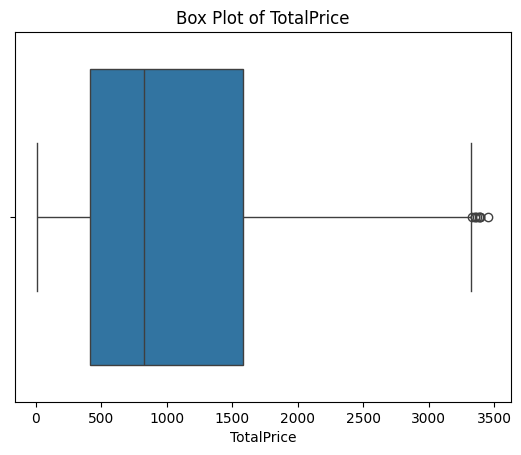

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['TotalPrice'])
plt.title('Box Plot of TotalPrice')
plt.show()

In [58]:
from scipy import stats

In [55]:
df['TotalPrice'].zscore

0       2.194447
1      -0.916341
2       2.072840
3      -0.952335
4       1.768690
          ...   
1195   -1.154993
1196    0.330657
1197   -0.219902
1198   -0.004743
1199    1.449463
Name: TotalPrice, Length: 1200, dtype: float64

In [59]:
df['ZScore'] = stats.zscore(df['TotalPrice'])
print("\n=== Z-Score Outliers ===")
print(f"Outliers found (|Z| > 3): {len(df[abs(df['ZScore']) > 3])}")


=== Z-Score Outliers ===
Outliers found (|Z| > 3): 0


<span style="color: #ead5d0; font-size: 28px; font-weight: bold;">
    put the edited data into excel file 
</span>

In [41]:
df.to_excel("D:\\cleaned_dataset_for_DataAnalytics.xlsx", index=False)